In [1]:
from datasets import load_dataset, Audio
import pandas as pd
import numpy as np

In [2]:
dataset = load_dataset(
    "urgent-challenge/urgent2025-sqa",
    split="blind_test_mos",
    streaming=True
)

print(dataset)

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

IterableDataset({
    features: ['audio', 'sample_id', 'system_id', 'mos', 'distill_mos', 'dnsmos_ovrl', 'estoi', 'lsd', 'mcd', 'pesq', 'pesqc2', 'sdr', 'nisqa_mos', 'lps', 'scoreq', 'sigmos_col', 'sigmos_disc', 'sigmos_loud', 'sigmos_noise', 'sigmos_ovrl', 'sigmos_reverb', 'sigmos_sig', 'spksim', 'sbert', 'utmos', 'raw_ratings'],
    num_shards: 9
})


In [3]:
dataset = dataset.cast_column(
    "audio",
    Audio(decode=False)
)

print(dataset.features)

{'audio': Audio(sampling_rate=None, decode=False, num_channels=None, stream_index=None), 'sample_id': Value('string'), 'system_id': Value('string'), 'mos': Value('float32'), 'distill_mos': Value('float32'), 'dnsmos_ovrl': Value('float32'), 'estoi': Value('float32'), 'lsd': Value('float32'), 'mcd': Value('float32'), 'pesq': Value('float32'), 'pesqc2': Value('float32'), 'sdr': Value('float32'), 'nisqa_mos': Value('float32'), 'lps': Value('float32'), 'scoreq': Value('float32'), 'sigmos_col': Value('float32'), 'sigmos_disc': Value('float32'), 'sigmos_loud': Value('float32'), 'sigmos_noise': Value('float32'), 'sigmos_ovrl': Value('float32'), 'sigmos_reverb': Value('float32'), 'sigmos_sig': Value('float32'), 'spksim': Value('float32'), 'sbert': Value('float32'), 'utmos': Value('float32'), 'raw_ratings': Value('null')}


In [4]:
sample = next(iter(dataset))

print(sample.keys())

dict_keys(['audio', 'sample_id', 'system_id', 'mos', 'distill_mos', 'dnsmos_ovrl', 'estoi', 'lsd', 'mcd', 'pesq', 'pesqc2', 'sdr', 'nisqa_mos', 'lps', 'scoreq', 'sigmos_col', 'sigmos_disc', 'sigmos_loud', 'sigmos_noise', 'sigmos_ovrl', 'sigmos_reverb', 'sigmos_sig', 'spksim', 'sbert', 'utmos', 'raw_ratings'])


In [5]:
for key,value in sample.items():
    print(f'{key}:{type(value)}')

audio:<class 'dict'>
sample_id:<class 'str'>
system_id:<class 'str'>
mos:<class 'float'>
distill_mos:<class 'float'>
dnsmos_ovrl:<class 'float'>
estoi:<class 'float'>
lsd:<class 'float'>
mcd:<class 'float'>
pesq:<class 'float'>
pesqc2:<class 'float'>
sdr:<class 'float'>
nisqa_mos:<class 'float'>
lps:<class 'float'>
scoreq:<class 'float'>
sigmos_col:<class 'float'>
sigmos_disc:<class 'float'>
sigmos_loud:<class 'float'>
sigmos_noise:<class 'float'>
sigmos_ovrl:<class 'float'>
sigmos_reverb:<class 'float'>
sigmos_sig:<class 'float'>
spksim:<class 'float'>
sbert:<class 'float'>
utmos:<class 'float'>
raw_ratings:<class 'NoneType'>


In [6]:
print("Sample ID:", sample["sample_id"])
print("System ID:", sample["system_id"])
print("Human MOS:", sample["mos"])

Sample ID: urgent25_blind_test_fileid_000001
System ID: urgent25_blind_test_submission_716
Human MOS: 1.5


In [7]:
samples = []

for i,sample in enumerate(dataset):
    samples.append(sample)

    if i == 999:
        break
print('collection:',len(samples))

collection: 1000


In [8]:
df = pd.DataFrame(samples)

print(df.shape)
df.head()

(1000, 26)


,audio,sample_id,system_id,mos,distill_mos,dnsmos_ovrl,estoi,lsd,mcd,pesq,...,sigmos_disc,sigmos_loud,sigmos_noise,sigmos_ovrl,sigmos_reverb,sigmos_sig,spksim,sbert,utmos,raw_ratings
0,"{'bytes': b'fLaC\x00\x00\x00""\x10\x00\x10\x00\...",urgent25_blind_test_fileid_000001,urgent25_blind_test_submission_716,1.500,1.502712,1.031564,0.545380,7.294332,12.526581,1.020256,...,3.215232,1.619186,1.001685,1.147591,2.721038,2.628586,0.467517,0.542822,1.271674,None
1,"{'bytes': b'fLaC\x00\x00\x00""\x10\x00\x10\x00\...",urgent25_blind_test_fileid_000002,urgent25_blind_test_submission_716,2.125,2.644538,2.117514,0.758396,5.236263,12.426147,1.112781,...,4.072666,2.163043,1.040700,1.368260,4.034642,3.229017,0.739662,0.854986,1.924129,None
2,"{'bytes': b'fLaC\x00\x00\x00""\x10\x00\x10\x00\...",urgent25_blind_test_fileid_000003,urgent25_blind_test_submission_716,3.750,3.279733,2.404439,0.790509,2.198061,7.143651,1.235009,...,3.052342,2.360568,1.644702,2.065739,4.440557,2.861775,0.945390,0.894247,3.309983,None
3,"{'bytes': b'fLaC\x00\x00\x00""\x10\x00\x10\x00\...",urgent25_blind_test_fileid_000004,urgent25_blind_test_submission_716,1.625,1.511546,1.634060,0.561297,5.002785,7.563825,1.064353,...,3.327051,3.004276,2.492324,1.884538,3.278852,2.549349,0.600803,0.725519,1.305997,None
4,"{'bytes': b'fLaC\x00\x00\x00""\x10\x00\x10\x00\...",urgent25_blind_test_fileid_000005,urgent25_blind_test_submission_716,3.625,3.833374,2.795569,0.925690,2.020970,5.595558,1.909567,...,2.904288,3.059780,2.179553,2.017733,4.005829,2.894397,0.930670,0.912687,4.003131,None


In [9]:
df['mos'].describe()

count    1000.000000
mean        2.027375
std         0.739151
min         1.000000
25%         1.500000
50%         1.875000
75%         2.500000
max         4.625000
Name: mos, dtype: float64

In [10]:
df['mos'].isna().sum()

np.int64(0)

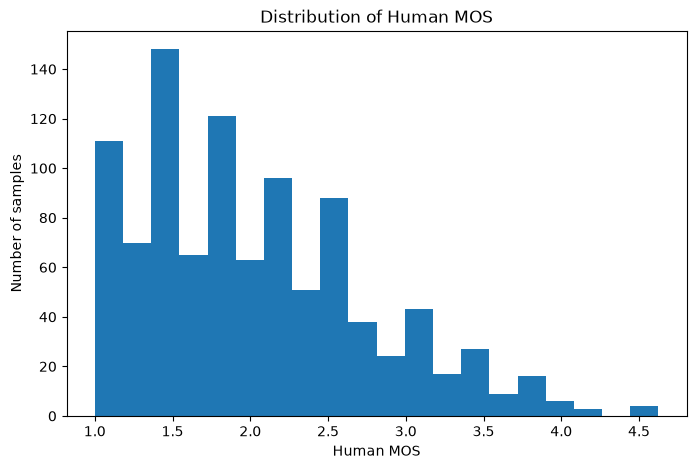

In [ ]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,5))
plt.hist(df['mos'],bins=20)
plt.xlabel('Human MOS')
plt.ylabel('Number of samples')
plt.title('Distribution of Human MOS')

plt.show()